In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [2]:
# Load dataset
df = pd.read_csv("/content/train.csv")

# View first 5 rows
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.info() # View rows, columns, and types
print(df.isnull().sum().sort_values(ascending=False)) # Missing values
print(df.duplicated().sum()) # Duplicate check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
#  Summary Statistics (Mean, SD, Quartiles) [cite: 39, 41, 42, 44]
print("\nSummary Statistics:\n", df.describe()) # [cite: 39]

#  Skewness & Kurtosis [cite: 45]
# Skew > 1 is highly skewed; Kurtosis > 3 has heavy tails [cite: 48, 49]
skewness = df.skew(numeric_only=True).sort_values(ascending=False) # [cite: 46]
print("\nTop Skewed Variables:\n", skewness.head(10))

Missing Values:
 PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

Duplicate count: 0

Summary Statistics:
                 Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.

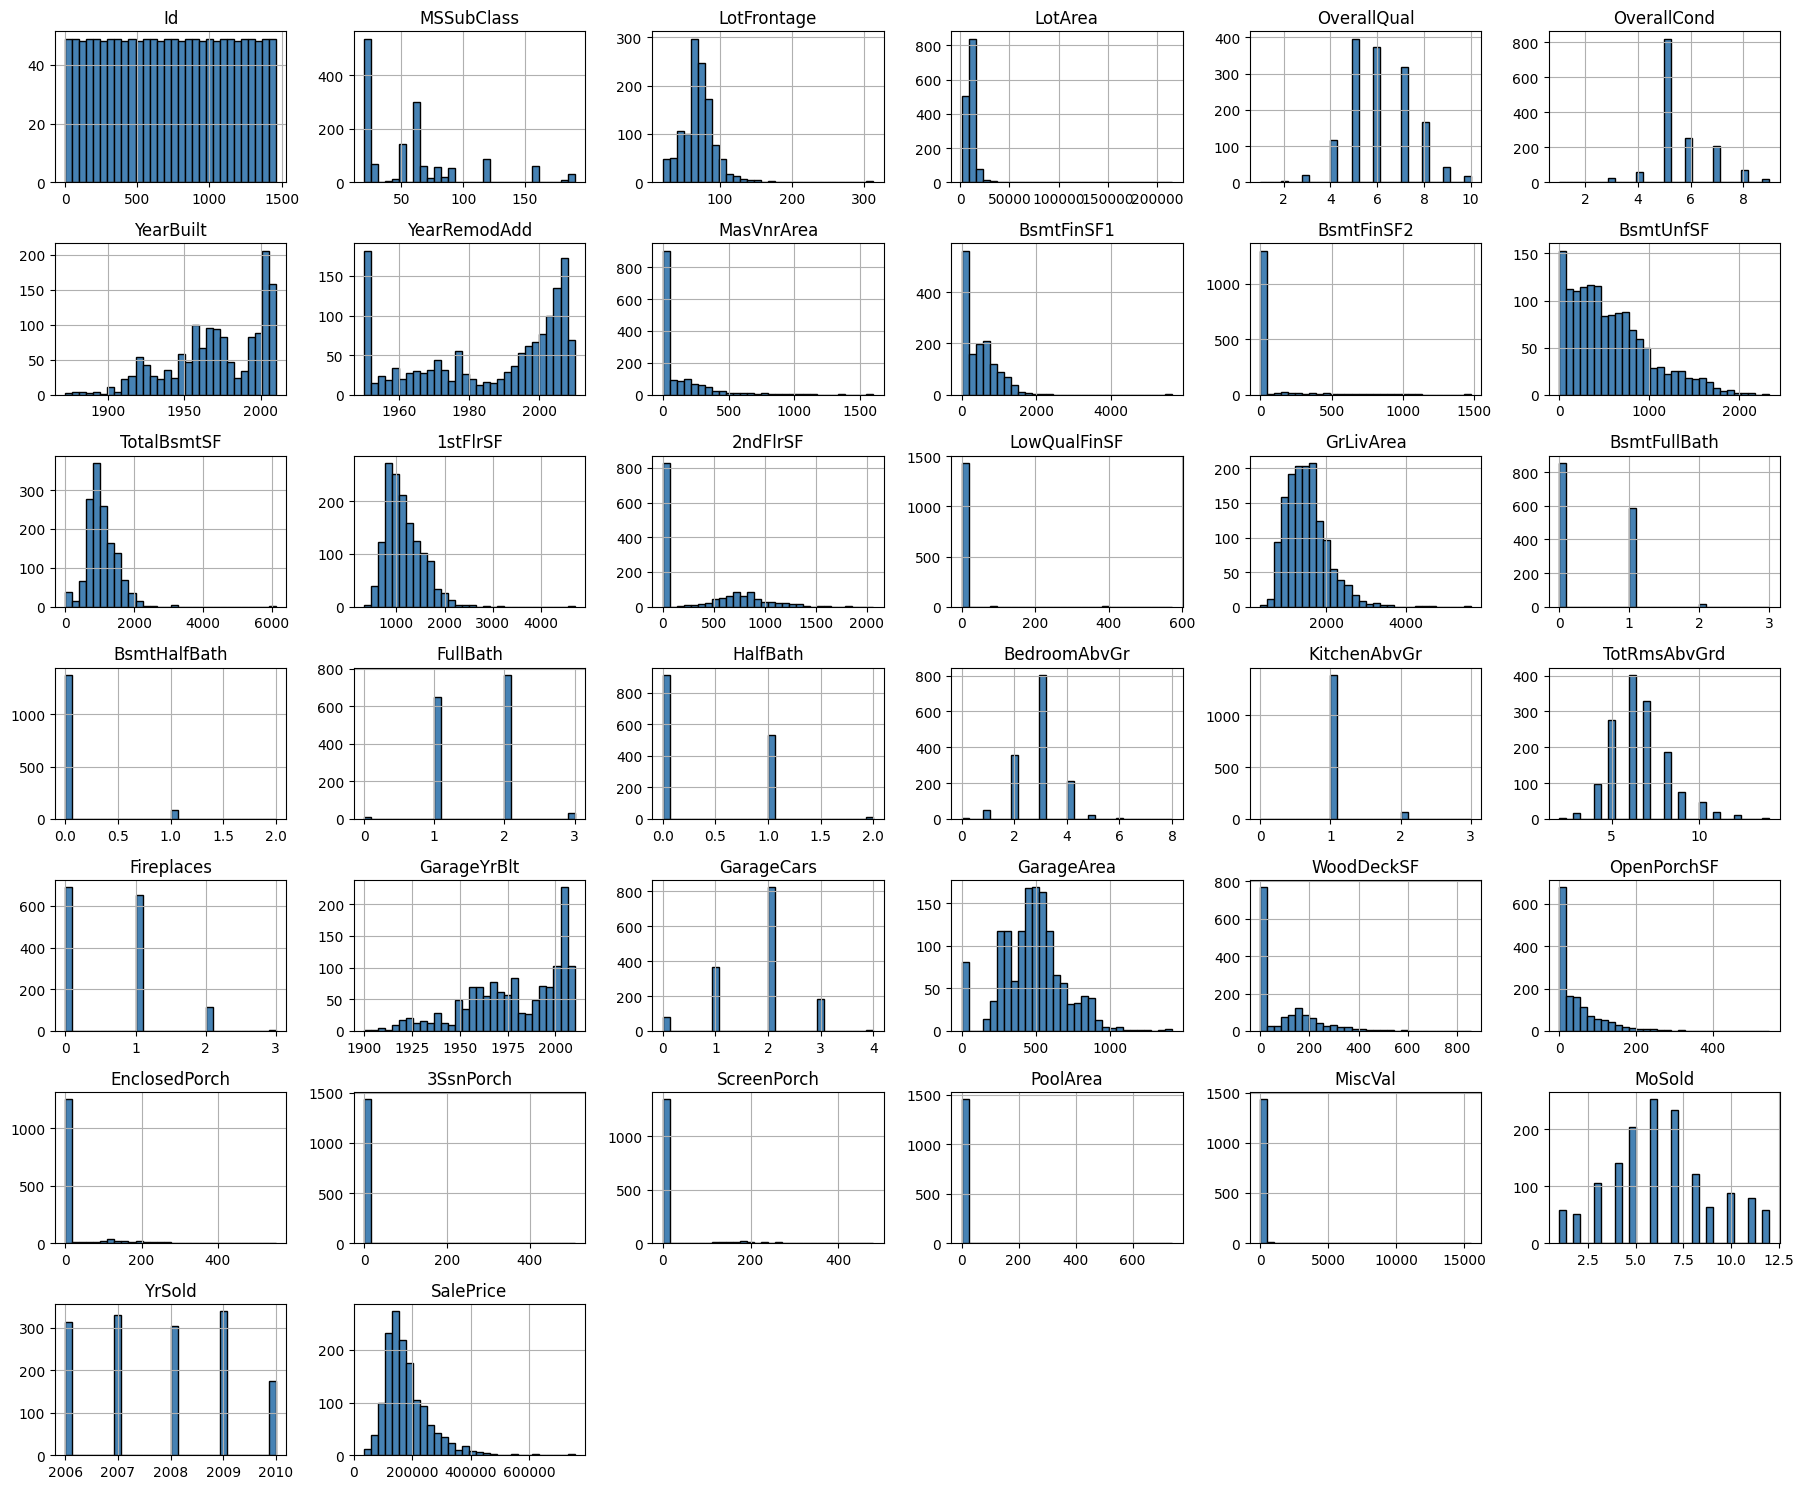

In [8]:
df.hist(bins=30, figsize=(18,15), color='steelblue', edgecolor='black')
plt.tight_layout()
plt.show()

5.2 KDE Plot (Target Variable)

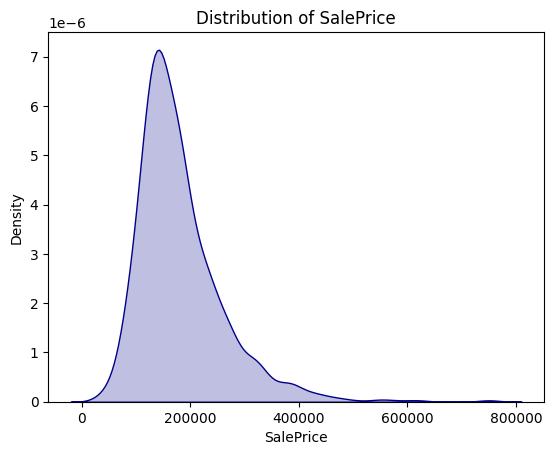

In [9]:
plt.figure()
sns.kdeplot(df['SalePrice'], fill=True, color='darkblue')
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.show()

5.3 Boxplot (Outlier Detection)

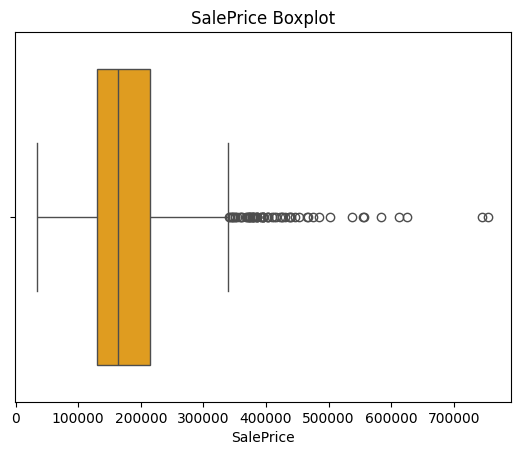

In [10]:
plt.figure()
sns.boxplot(x=df['SalePrice'], color='orange')
plt.title("SalePrice Boxplot")
plt.show()

5.4 Correlation Heatmap (Professional)

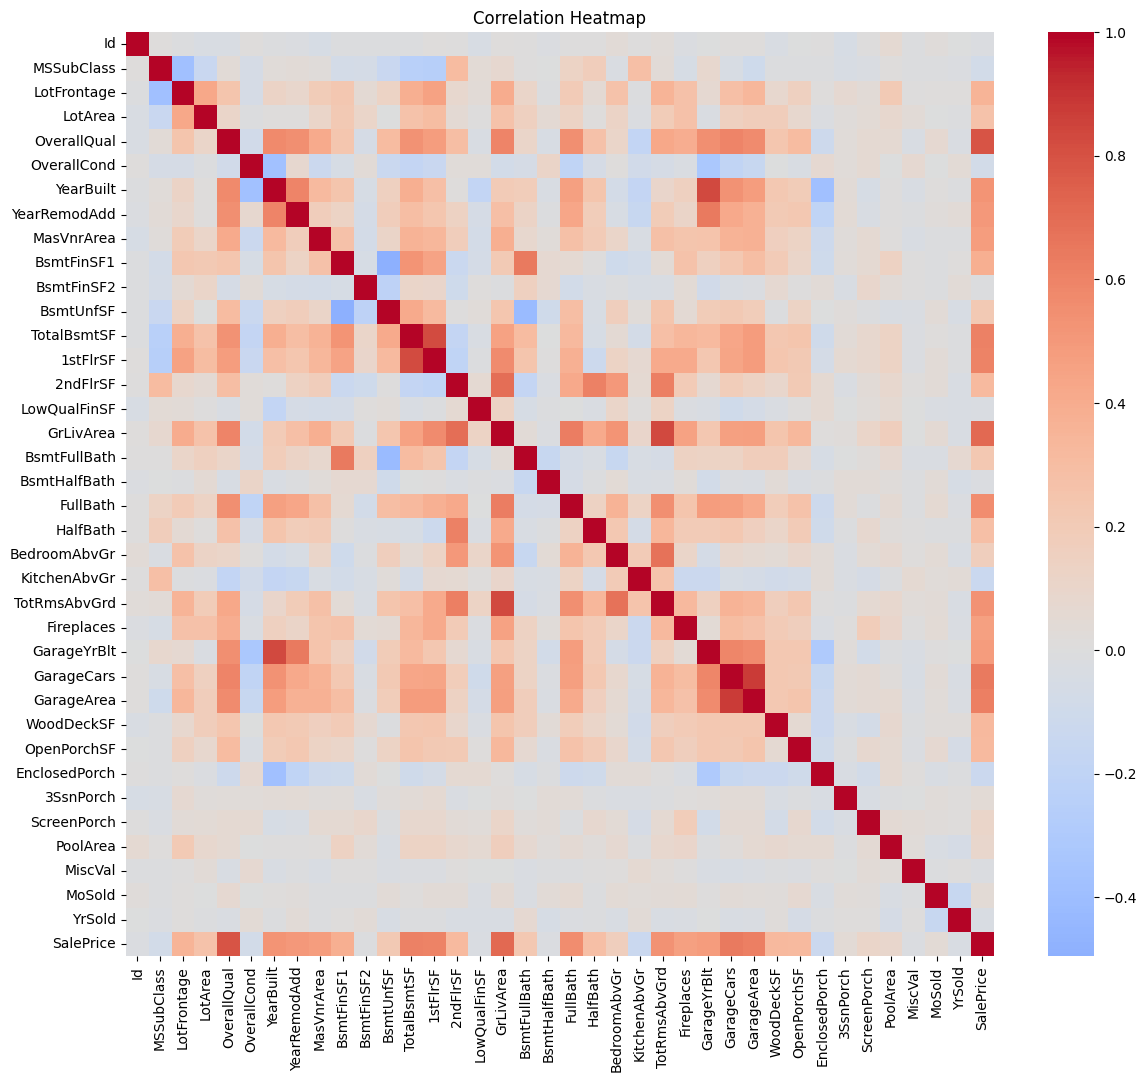

In [11]:
plt.figure(figsize=(14,12))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

Strongest Features with SalePrice

In [12]:
corr_matrix['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


Top 5 Positive Correlations

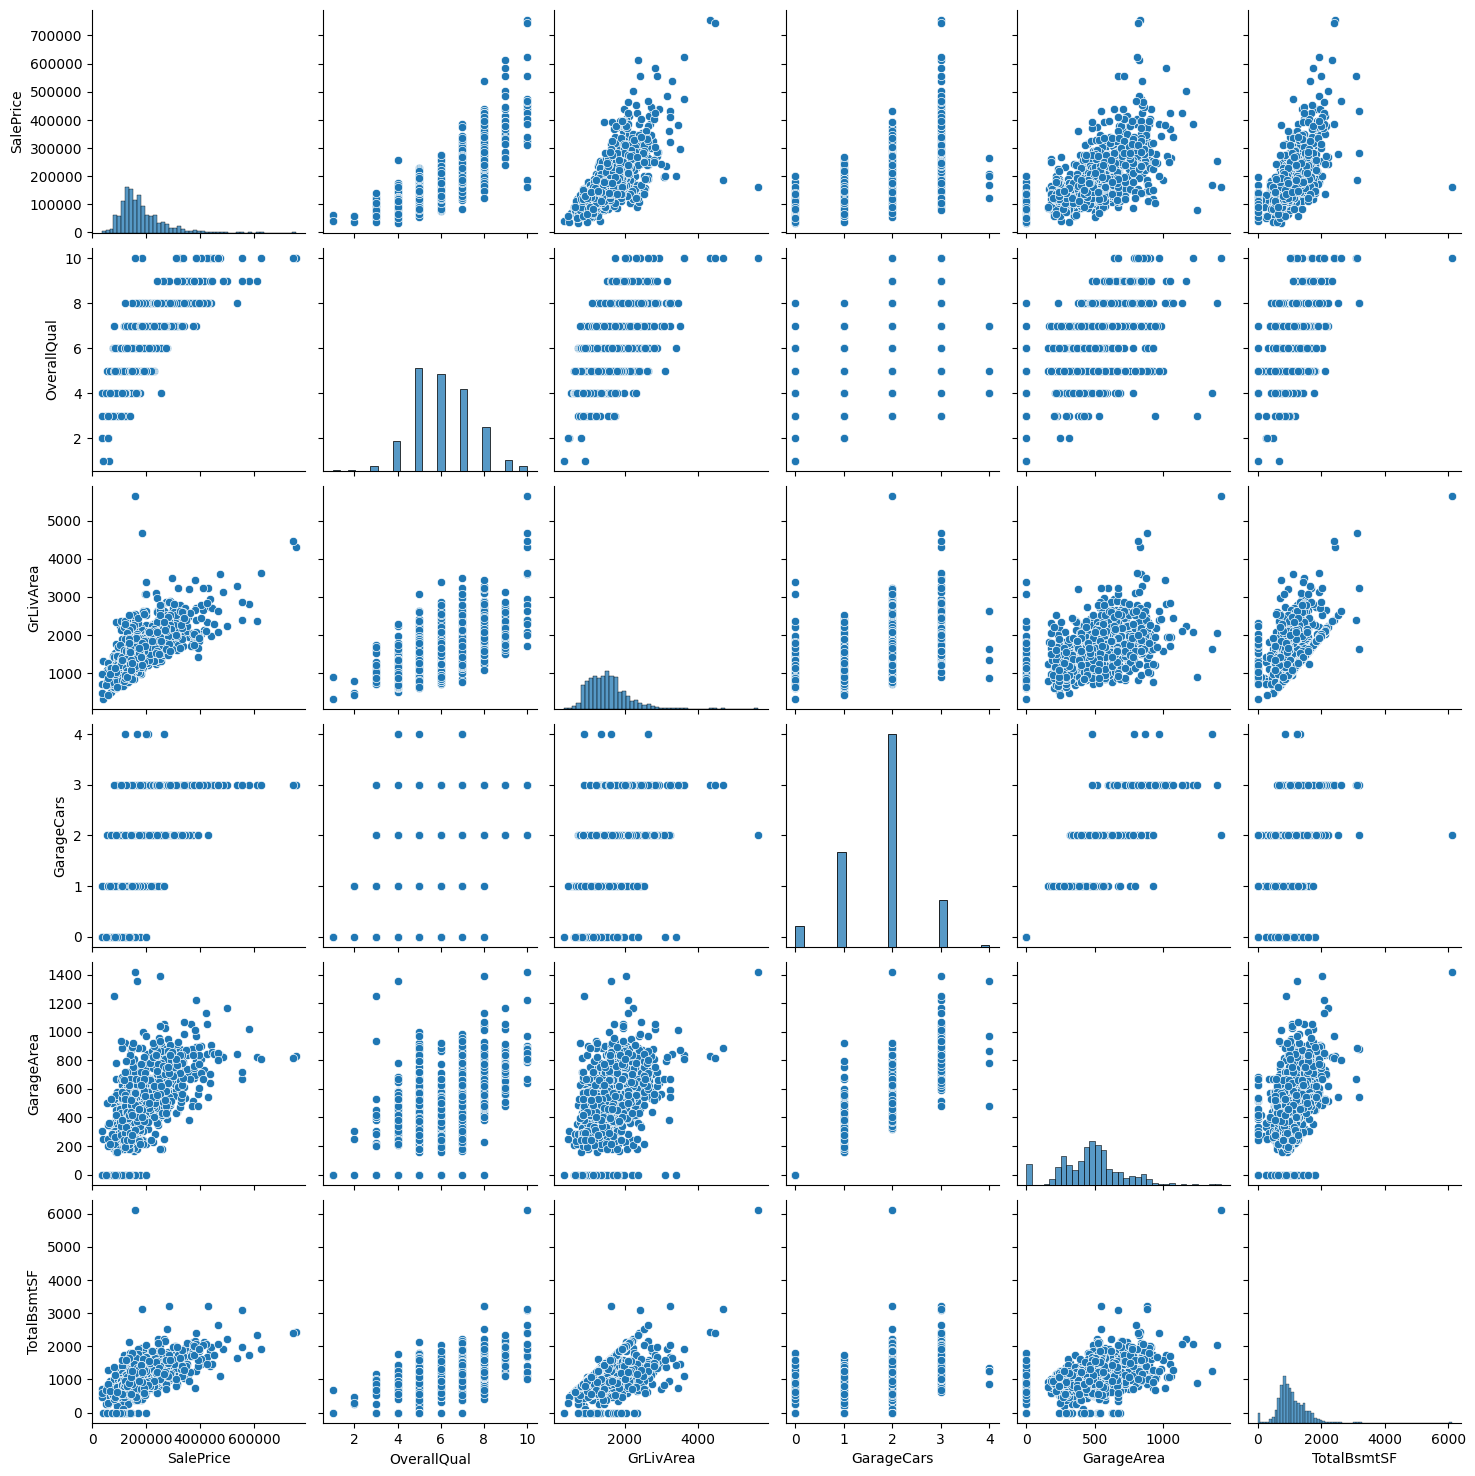

In [13]:
top_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(6).index

sns.pairplot(df[top_features])
plt.show()

Exercise 1 – 5 Highly Skewed Variables

In [17]:
skewness[skewness > 1].head(5)



,0
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341


In [18]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

In [19]:
sns.set_palette("deep")